<a href="https://colab.research.google.com/github/IYORIYAGAMI/OPEN-SOURCE/blob/main/rain_forcast_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv('/content/mumbai-monthly-rains.csv')
df.head()

,Year,Jan,Feb,Mar,April,May,June,July,Aug,Sept,Oct,Nov,Dec,Total
0,1901,13.116602,0.000000,0.000000,3.949669,17.139791,640.714036,888.369692,545.045796,64.271513,9.871696,0.000000,0.000000,2182.478796
1,1902,0.000000,0.000000,0.000000,0.000000,0.355001,247.998782,408.433730,566.595863,688.913455,28.654092,0.488864,19.526547,1960.966334
2,1903,0.000000,0.000000,0.844034,0.000000,220.568740,370.849048,902.447896,602.420828,264.589816,157.892877,0.000000,0.000000,2519.613240
3,1904,0.000000,0.000000,11.381769,0.000000,0.000000,723.081969,390.886799,191.581927,85.704754,38.679948,0.000000,0.000000,1441.317168
4,1905,0.662561,1.713452,0.000000,0.000000,0.000000,123.870892,581.827975,167.382149,172.297723,7.365924,24.903575,0.000000,1080.024250


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Year    121 non-null    int64  
 1   Jan     121 non-null    float64
 2   Feb     121 non-null    float64
 3   Mar     121 non-null    float64
 4   April   121 non-null    float64
 5   May     121 non-null    float64
 6   June    121 non-null    float64
 7   July    121 non-null    float64
 8   Aug     121 non-null    float64
 9   Sept    121 non-null    float64
 10  Oct     121 non-null    float64
 11  Nov     121 non-null    float64
 12  Dec     121 non-null    float64
 13  Total   121 non-null    float64
dtypes: float64(13), int64(1)
memory usage: 13.4 KB


In [ ]:
df.describe()

,Year,Jan,Feb,Mar,April,May,June,July,Aug,Sept,Oct,Nov,Dec,Total
count,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000
mean,1961.000000,1.567235,0.929358,0.869231,1.428458,18.183632,517.854402,757.407412,465.600818,312.885747,73.983526,13.849462,3.556428,2168.115709
std,35.073732,6.462247,3.077050,2.890032,7.371307,48.628812,251.067016,285.836188,249.072915,205.135368,96.686113,29.689941,12.342390,533.263926
min,1901.000000,0.000000,0.000000,0.000000,0.000000,0.000000,61.058662,103.209194,87.493370,36.313545,0.000000,0.000000,0.000000,1058.840525
25%,1931.000000,0.000000,0.000000,0.000000,0.000000,0.000000,324.094617,540.745923,268.002392,149.584208,9.871696,0.000000,0.000000,1834.996957
50%,1961.000000,0.000000,0.000000,0.000000,0.000000,0.355001,482.449872,788.403637,445.870342,269.276549,43.479170,1.066086,0.000000,2126.054987
75%,1991.000000,0.000000,0.152298,0.000000,0.194165,4.208322,678.040770,942.616099,604.372615,398.645218,98.235161,9.373154,0.176149,2478.558089
max,2021.000000,51.348290,21.107118,18.252996,75.541818,234.392757,1219.518576,1358.833554,1200.956558,987.796660,552.902707,164.348387,90.044602,3563.259531


In [ ]:
df.isna().sum()

,0
Year,0
Jan,0
Feb,0
Mar,0
April,0
May,0
June,0
July,0
Aug,0
Sept,0


In [ ]:
df_long = df.melt(
    id_vars='Year',
    value_vars=['Jan','Feb','Mar','April','May','June','July','Aug','Sept','Oct','Nov','Dec'],
    var_name='Month',
    value_name='Rainfall'
)

In [ ]:
month_map = {
    'Jan':1,'Feb':2,'Mar':3,'April':4,'May':5,'June':6,
    'July':7,'Aug':8,'Sept':9,'Oct':10,'Nov':11,'Dec':12
}

df_long['Month'] = df_long['Month'].map(month_map)

In [ ]:
df_long['Date'] = pd.to_datetime(
    df_long['Year'].astype(str) + '-' + df_long['Month'].astype(str)
)

df_long = df_long.sort_values('Date')
df_long.set_index('Date', inplace=True)

df_long.head()

,Year,Month,Rainfall
Date,,,
1901-01-01,1901,1,13.116602
1901-02-01,1901,2,0.000000
1901-03-01,1901,3,0.000000
1901-04-01,1901,4,3.949669
1901-05-01,1901,5,17.139791


In [ ]:
df_long.isna().sum()

,0
Year,0
Month,0
Rainfall,0


In [ ]:
df_long['Rainfall'] = df_long['Rainfall'].clip(lower=0)

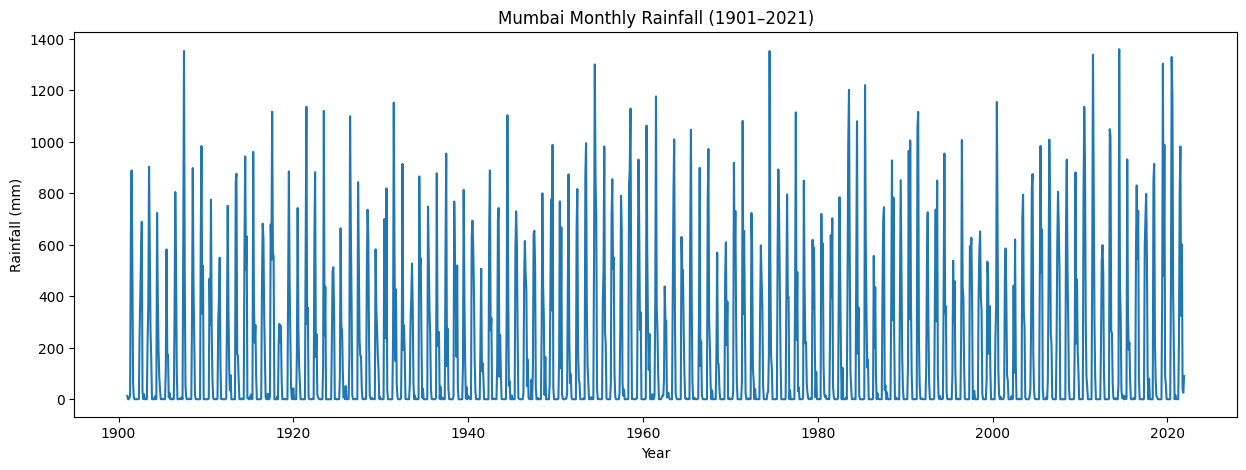

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(df_long.index, df_long['Rainfall'])
plt.title('Mumbai Monthly Rainfall (1901–2021)')
plt.xlabel('Year')
plt.ylabel('Rainfall (mm)')
plt.show()

/tmp/ipython-input-3074862714.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly_rain = df_long['Rainfall'].resample('Y').sum()


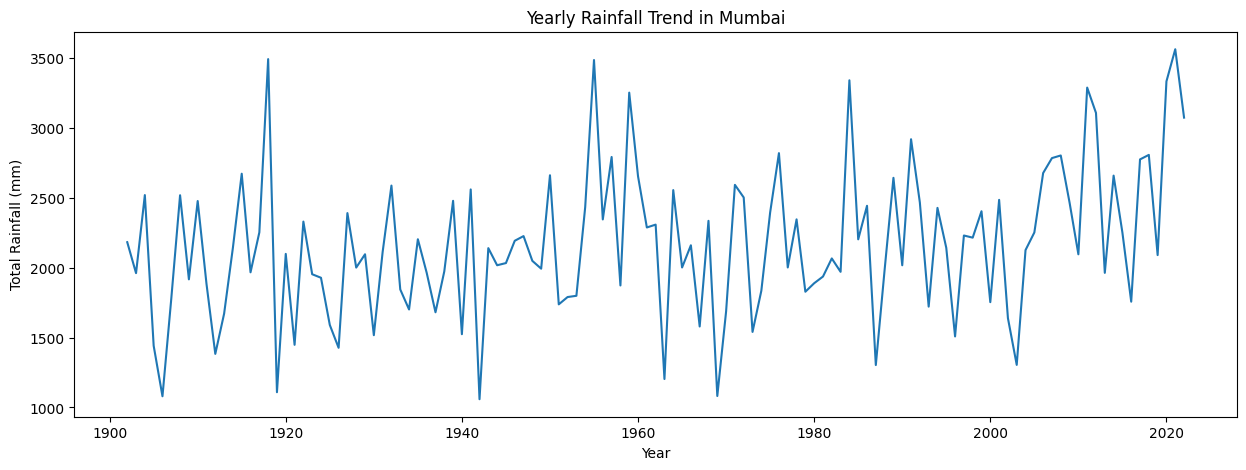

In [ ]:
yearly_rain = df_long['Rainfall'].resample('Y').sum()

plt.figure(figsize=(15,5))
plt.plot(yearly_rain)
plt.title('Yearly Rainfall Trend in Mumbai')
plt.xlabel('Year')
plt.ylabel('Total Rainfall (mm)')
plt.show()

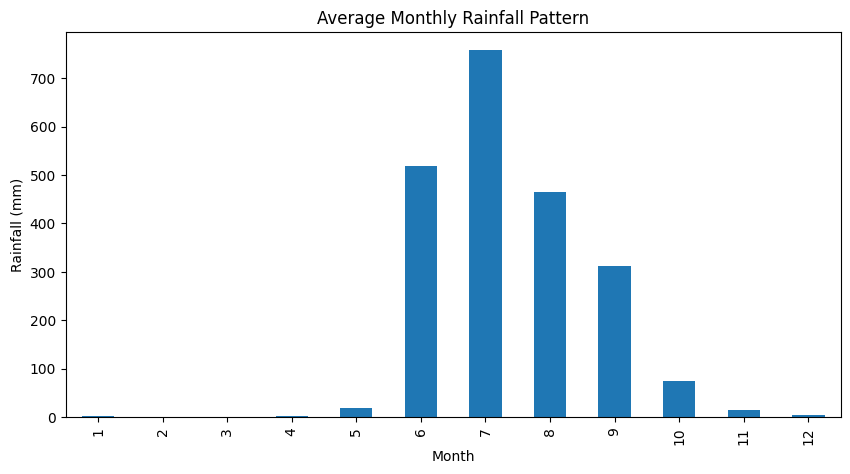

In [ ]:
monthly_avg = df_long.groupby(df_long.index.month)['Rainfall'].mean()

plt.figure(figsize=(10,5))
monthly_avg.plot(kind='bar')
plt.title('Average Monthly Rainfall Pattern')
plt.xlabel('Month')
plt.ylabel('Rainfall (mm)')
plt.show()

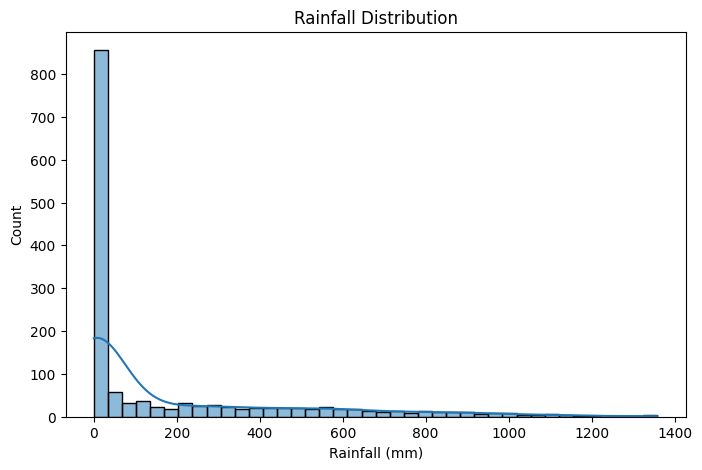

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df_long['Rainfall'], bins=40, kde=True)
plt.title('Rainfall Distribution')
plt.xlabel('Rainfall (mm)')
plt.show()

In [ ]:
ts = df_long['Rainfall']

In [ ]:
train = ts[:'2010-12-01']
test = ts['2011-01-01':]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 1320
Test size: 132


In [ ]:
naive_pred = test.shift(1)
naive_pred = naive_pred.dropna()
test_aligned = test[1:]

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_naive = mean_absolute_error(test_aligned, naive_pred)
rmse_naive = np.sqrt(mean_squared_error(test_aligned, naive_pred))

print("Naive MAE:", mae_naive)
print("Naive RMSE:", rmse_naive)

Naive MAE: 191.98153430735877
Naive RMSE: 348.1696191828846


In [ ]:
import pickle
from statsmodels.tsa.statespace.sarimax import SARIMAX

ts = ts.asfreq("MS")
ts = ts.fillna(method="ffill")

model = SARIMAX(
    ts,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=True,
    enforce_invertibility=True
)

model_fit = model.fit(disp=False)

print(model_fit.summary())

pickle.dump(model_fit, open("sarima_model.pkl", "wb"))
pickle.dump(ts, open("rainfall_series.pkl", "wb"))


/tmp/ipython-input-3427153447.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ts = ts.fillna(method="ffill")


                                     SARIMAX Results                                      
Dep. Variable:                           Rainfall   No. Observations:                 1452
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -9257.914
Date:                            Fri, 13 Feb 2026   AIC                          18525.829
Time:                                    09:50:52   BIC                          18552.187
Sample:                                01-01-1901   HQIC                         18535.669
                                     - 12-01-2021                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0129      0.018      0.734      0.463      -0.022       0.047
ma.L1         -0.9999      0.179   

In [ ]:
sarima_pred = sarima_fit.forecast(steps=len(test))
sarima_pred.index = test.index

In [ ]:
mae_sarima = mean_absolute_error(test, sarima_pred)
rmse_sarima = np.sqrt(mean_squared_error(test, sarima_pred))

print("SARIMA MAE:", mae_sarima)
print("SARIMA RMSE:", rmse_sarima)

SARIMA MAE: 100.99843574967802
SARIMA RMSE: 186.51325534873175


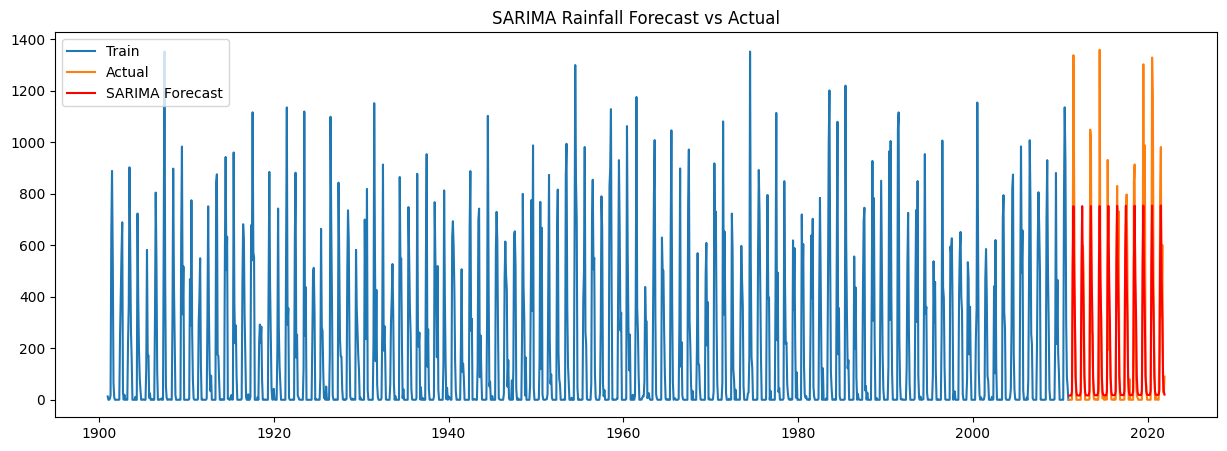

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(train, label='Train')
plt.plot(test, label='Actual')
plt.plot(sarima_pred, label='SARIMA Forecast', color='red')
plt.legend()
plt.title('SARIMA Rainfall Forecast vs Actual')
plt.show()

In [ ]:
sarima_fit = sarima_model.fit()

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pickle

final_model = SARIMAX(
    ts,
    order=(0,1,1),
    seasonal_order=(0,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_model_fit = final_model.fit()

with open("sarima_model.pkl", "wb") as f:
    pickle.dump(final_model_fit, f)

with open("rainfall_series.pkl", "wb") as f:
    pickle.dump(ts, f)

print("Files saved successfully")

Files saved successfully


In [ ]:
import os

print(os.path.getsize("sarima_model.pkl"))
print(os.path.getsize("rainfall_series.pkl"))

160856181
35861


In [ ]:
from google.colab import files

files.download("sarima_model.pkl")
files.download("rainfall_series.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

open a new file name app.py and upload use the code below

In [ ]:
import streamlit as st
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

st.set_page_config(page_title="Rainfall Predictor", layout="centered")

st.title("Mumbai Rainfall Forecast")

model = pickle.load(open("sarima_model.pkl", "rb"))
history = pickle.load(open("rainfall_series.pkl", "rb"))

n_months = st.slider("Select months to forecast", 1, 36, 12)

forecast_obj = model.get_forecast(steps=n_months)

pred = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

lower = conf_int.iloc[:, 0]
upper = conf_int.iloc[:, 1]

forecast_df = pd.DataFrame({
    "Month": pred.index.strftime("%Y-%m"),
    "Predicted Rainfall (mm)": pred.values.round(2),
    "Lower CI": lower.values.round(2),
    "Upper CI": upper.values.round(2)
})

st.subheader("Forecast Table")
st.dataframe(forecast_df, use_container_width=True)

st.subheader("Forecast Chart")
st.line_chart(pred)

st.subheader("Detailed Forecast Plot")

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(history[-120:], label="Historical Rainfall", color="blue")

ax.plot(pred, label="Forecast", color="red")

ax.fill_between(pred.index, lower, upper, color="pink", alpha=0.3, label="Confidence Interval")

ax.set_xlabel("Date")
ax.set_ylabel("Rainfall (mm)")
ax.set_title("Mumbai Rainfall Forecast (SARIMA)")
ax.legend()

st.pyplot(fig)